## Overview

`Melcher25` models the meridional buoyancy gradient $\Delta b$ and buoyancy flux $B$ as a coupled stochastic system:

$$\frac{d(\Delta b)}{dt} = -B - \left|q_0 + q_1(\Delta b - b_0)\right|(\Delta b - b_0) + \sigma\,dW$$

$$\frac{dB}{dt} = \frac{\Delta b + \alpha B - \gamma}{\tau} + \sigma\,dW$$

The nonlinear restoring force creates two stable fixed points — the bistable potential wells corresponding to the stadial and interstadial states. Noise $\sigma\,dW$ drives spontaneous transitions between them.

### Parameters

| Name | Description | Default |
|---|---|---|
| `sigma` | Noise amplitude (both state variables) | 0.2 |
| `gamma` | External forcing ∝ atmospheric CO₂ | 1.5 |
| `alpha` | Southern Ocean AABW coupling | 0.0 |
| `b0` | Centre of the bistable potential well | 0.625 |
| `q0` | Constant term in restoring force | −9.0 |
| `q1` | Linear coefficient in restoring force | 12.0 |
| `tau` | Buoyancy-flux relaxation timescale | 0.902 |

`b0`, `q0`, `q1`, `tau` are calibrated from NGRIP (Melcher et al. 2025). `sigma`, `gamma`, and `alpha` support time-varying values via callables or `Forcing` objects.

State variables: `db` ($\Delta b$), `B`.  
Diagnostic variable: `states` (auto-populated after every `integrate()` call).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from climatecritters.model_critters.melcher25 import (
    Melcher25, classify_bistable_states
)

## Generate a synthetic DO record

In [2]:
model = Melcher25(sigma=0.2, gamma=1.5, alpha=-0.4)

output = model.integrate(
    t_span=(0, 599.88), y0=[1.0, 0.0],
    method='heun_maruyama', dt=0.012,
    kwargs={'random_seed': 42, 'si': 0.12},
)

db     = output.state_variables['db']
B      = output.state_variables['B']
t      = output.time
states = output.diagnostic_variables['states']   # 1 = stadial, 0 = interstadial

stadial_thresh     = model.stadial_threshold
interstadial_thresh = model.interstadial_threshold

n_events = int(np.sum(np.diff(states) == -1))
print(f'Stadial threshold:      {stadial_thresh:.3f}')
print(f'Interstadial threshold: {interstadial_thresh:.3f}')
print(f'Number of DO events:    {n_events}')

Stadial threshold:      1.018
Interstadial threshold: 1.375
Number of DO events:    35


### Δb time series with detected tipping points

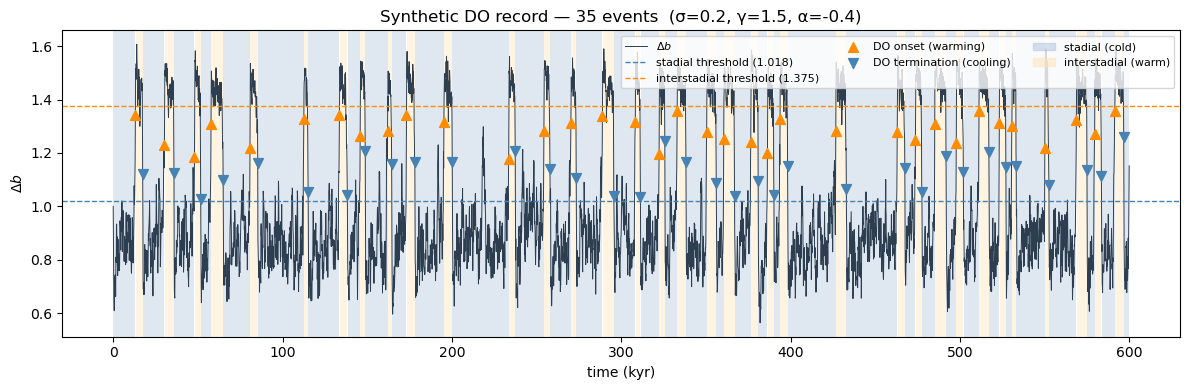

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))

# shade stadial (cold) and interstadial (warm) periods
in_stadial = states == 1
transitions = np.where(np.diff(states.astype(int)) != 0)[0]
boundaries  = np.concatenate([[0], transitions + 1, [len(states)]])

for i in range(len(boundaries) - 1):
    sl = slice(boundaries[i], boundaries[i + 1])
    color = '#b0c4de' if states[boundaries[i]] == 1 else '#ffe4b5'
    ax.axvspan(t[sl][0], t[sl][-1], color=color, alpha=0.4, lw=0)

# Δb time series
ax.plot(t, db, lw=0.7, color='#2c3e50', label=r'$\Delta b$')

# threshold lines
ax.axhline(stadial_thresh,      ls='--', lw=1.0, color='steelblue',  label=f'stadial threshold ({stadial_thresh:.3f})')
ax.axhline(interstadial_thresh, ls='--', lw=1.0, color='darkorange', label=f'interstadial threshold ({interstadial_thresh:.3f})')

# mark tipping-point transitions
do_onsets   = np.where(np.diff(states) == -1)[0]   # stadial → interstadial
do_offsets  = np.where(np.diff(states) ==  1)[0]   # interstadial → stadial
ax.scatter(t[do_onsets],  db[do_onsets],  marker='^', s=50, color='darkorange', zorder=5, label='DO onset (warming)')
ax.scatter(t[do_offsets], db[do_offsets], marker='v', s=50, color='steelblue',  zorder=5, label='DO termination (cooling)')

patch_s = mpatches.Patch(color='#b0c4de', alpha=0.5, label='stadial (cold)')
patch_i = mpatches.Patch(color='#ffe4b5', alpha=0.5, label='interstadial (warm)')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [patch_s, patch_i], fontsize=8, ncol=3, loc='upper right')

ax.set_xlabel('time (kyr)')
ax.set_ylabel(r'$\Delta b$')
ax.set_title(f'Synthetic DO record — {n_events} events  (σ={model.sigma}, γ={model.gamma}, α={model.alpha})')
plt.tight_layout()
plt.show()

**Figure.** Synthetic $\Delta b$ time series with automatically detected stadial (blue shading) and interstadial (orange shading) periods. Orange triangles mark DO onset events (abrupt warmings); blue triangles mark terminations (gradual coolings). Dashed lines show the Jacobian-derived hysteresis thresholds from `model.stadial_threshold` and `model.interstadial_threshold`,these are computed analytically from the model constants and are set automatically after every `integrate()` call.

## Both state variables: Δb and B

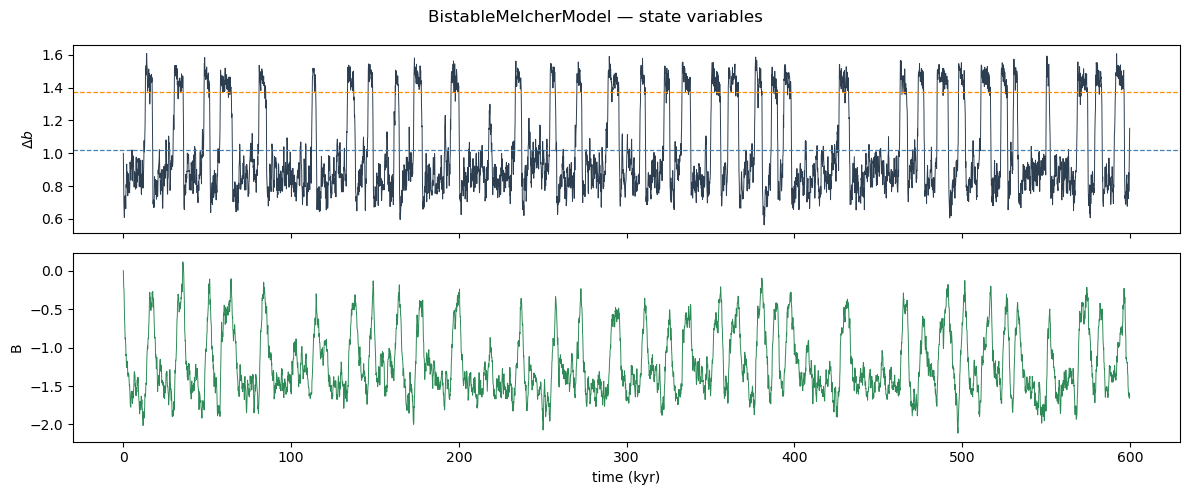

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(t, db, lw=0.7, color='#2c3e50')
axes[0].set_ylabel(r'$\Delta b$')
axes[0].axhline(stadial_thresh,      ls='--', lw=0.9, color='steelblue')
axes[0].axhline(interstadial_thresh, ls='--', lw=0.9, color='darkorange')

axes[1].plot(t, B, lw=0.7, color='seagreen')
axes[1].set_ylabel('B')
axes[1].set_xlabel('time (kyr)')

fig.suptitle('Melcher25 — state variables')
plt.tight_layout()
plt.show()

**Figure.** Top: primary state variable $\Delta b$ (meridional buoyancy gradient) with hysteresis thresholds. Bottom: buoyancy flux $B$, which relaxes on timescale $\tau$ and acts as the slow variable that mediates transitions. The asymmetry between fast warmings and slower coolings is controlled by `alpha`.

## Inspect all parameters

In [5]:
model.doc('parameters')


Parameters — Melcher25
══════════════════════════════════════════════════════════════════════════
Name   Current value  Description
──────────────────────────────────────────────────────────────────────────
sigma  0.2            Noise amplitude applied to both state variables.
                      Range [0.15, 0.4]. Default is 0.2.
gamma  1.5            External forcing proportional to atmospheric CO2.
                      Bistable behaviour occurs near γ ≈ 1.5; range [0.8,
                      3.2]. If callable, must follow the signature
                      contract in ``contracts/signal_model_contract.md``:
                      ``(t)``, ``(t, state)``, or ``(t, state, model)``
                      with the first argument named ``t`` or ``time``.
                      Default is 1.5.
alpha  -0.4           Southern Ocean AABW coupling; controls the asymmetry
                      between stadial and interstadial durations. Range
                      [-1.0, 0.0]. If callable, m

## Effect of noise amplitude σ

Higher `sigma` drives more frequent and less predictable transitions; lower `sigma` produces longer dwell times in each state.

In [6]:
sigmas = [0.15, 0.2, 0.3, 0.4]
sigma_outputs = {}

for s in sigmas:
    m = Melcher25(sigma=s, gamma=1.5, alpha=-0.4)
    out = m.integrate(
        t_span=(0, 599.88), y0=[1.0, 0.0],
        method='heun_maruyama', dt=0.012,
        kwargs={'random_seed': 42, 'si': 0.12},
    )
    n = int(np.sum(np.diff(out.diagnostic_variables['states']) == -1))
    sigma_outputs[s] = (out, n)
    print(f'sigma={s:.2f} → {n} DO events')

sigma=0.15 → 22 DO events
sigma=0.20 → 35 DO events
sigma=0.30 → 62 DO events
sigma=0.40 → 83 DO events


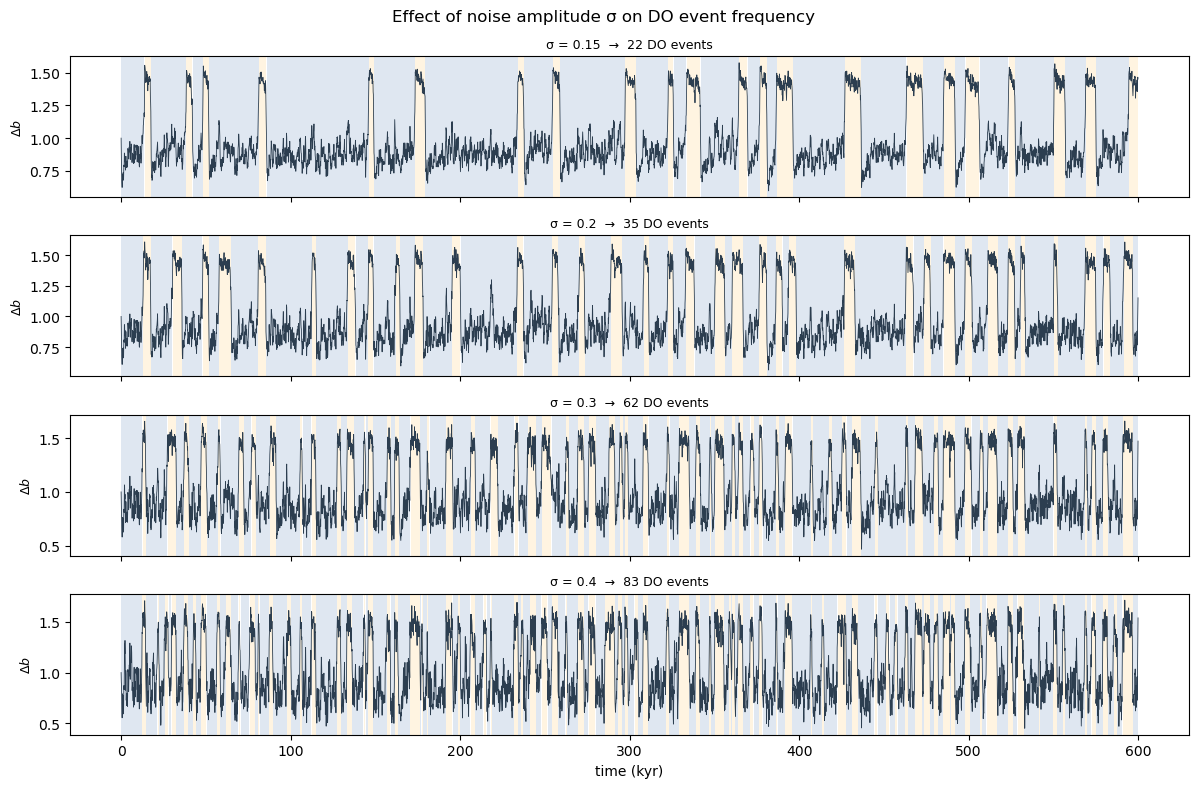

In [7]:
fig, axes = plt.subplots(len(sigmas), 1, figsize=(12, 8), sharex=True)

for ax, s in zip(axes, sigmas):
    out, n = sigma_outputs[s]
    db_s = out.state_variables['db']
    st_s = out.diagnostic_variables['states']
    t_s  = out.time

    boundaries = np.concatenate([[0], np.where(np.diff(st_s.astype(int)) != 0)[0] + 1, [len(st_s)]])
    for i in range(len(boundaries) - 1):
        sl = slice(boundaries[i], boundaries[i + 1])
        color = '#b0c4de' if st_s[boundaries[i]] == 1 else '#ffe4b5'
        ax.axvspan(t_s[sl][0], t_s[sl][-1], color=color, alpha=0.4, lw=0)

    ax.plot(t_s, db_s, lw=0.6, color='#2c3e50')
    ax.set_ylabel(r'$\Delta b$', fontsize=9)
    ax.set_title(f'σ = {s}  →  {n} DO events', fontsize=9)

axes[-1].set_xlabel('time (kyr)')
fig.suptitle('Effect of noise amplitude σ on DO event frequency')
plt.tight_layout()
plt.show()

**Figure.** Four runs with identical parameters except `sigma`. Low noise ($\sigma=0.15$) produces rare, widely-spaced transitions; high noise ($\sigma=0.4$) drives rapid flickering. The NGRIP-calibrated default is $\sigma=0.2$.

## Reclassify after adding proxy noise

In real palaeoclimate records, $\Delta b$ is measured with proxy noise. `classify_bistable_states` lets you reclassify a noisy signal using the same hysteresis thresholds without re-running the SDE.

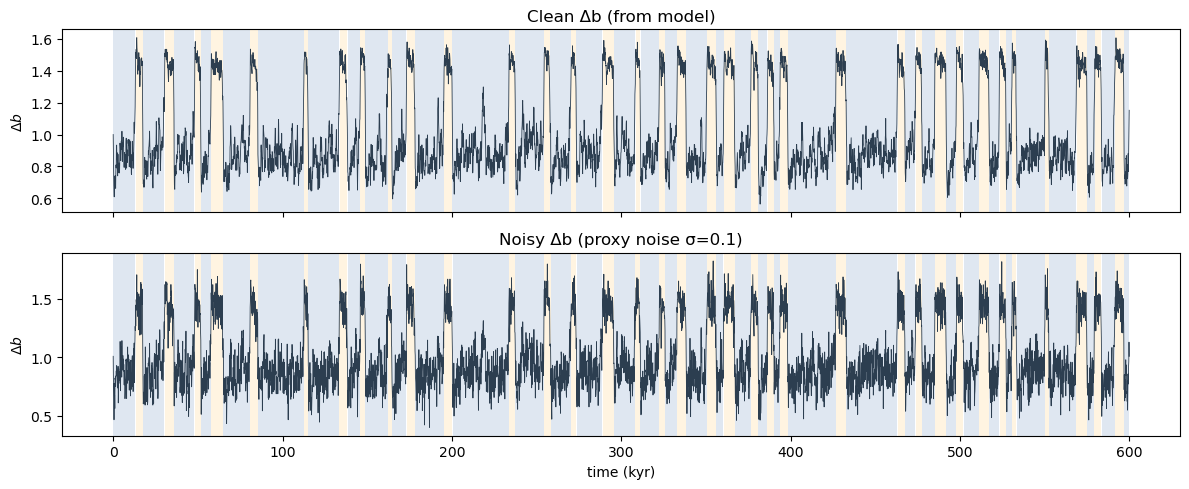

In [10]:
rng      = np.random.default_rng(99)
noisy_db = db + rng.normal(0, 0.1, len(db))

states_noisy = classify_bistable_states(noisy_db, alpha=-0.4)

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

for ax, sig, st, title in zip(
    axes,
    [db, noisy_db],
    [states, states_noisy],
    ['Clean Δb (from model)', 'Noisy Δb (proxy noise σ=0.1)'],
):
    boundaries = np.concatenate([[0], np.where(np.diff(st.astype(int)) != 0)[0] + 1, [len(st)]])
    for i in range(len(boundaries) - 1):
        sl = slice(boundaries[i], boundaries[i + 1])
        color = '#b0c4de' if st[boundaries[i]] == 1 else '#ffe4b5'
        ax.axvspan(t[sl][0], t[sl][-1], color=color, alpha=0.4, lw=0)
    ax.plot(t, sig, lw=0.6, color='#2c3e50')
    ax.set_ylabel(r'$\Delta b$')
    ax.set_title(title)

axes[-1].set_xlabel('time (kyr)')
plt.tight_layout()
plt.show()

**Figure.** Top: clean $\Delta b$ from the model with automatically classified states. Bottom: the same series after adding Gaussian proxy noise ($\sigma=0.1$), reclassified with `classify_bistable_states`. The hysteresis logic suppresses spurious flickering near the thresholds, so the state boundaries remain stable despite the added noise.